Task 4-1: Compare 3 pretrained models (ResNet50, MobileNetV3, EfficientNet-B0) 

In [13]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# If pretrained weights download fails on macOS due to SSL, run this cell once.
import os
import ssl
import urllib.request

try:
    import certifi

    cafile = certifi.where()
    os.environ.setdefault("SSL_CERT_FILE", cafile)
    os.environ.setdefault("REQUESTS_CA_BUNDLE", cafile)

    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=cafile)
    urllib.request.install_opener(
        urllib.request.build_opener(
            urllib.request.HTTPSHandler(context=ssl.create_default_context(cafile=cafile))
        )
    )
    print("SSL configured:", cafile)
except Exception as e:
    print("SSL helper skipped:", e)

SSL configured: /usr/local/lib/python3.12/dist-packages/certifi/cacert.pem


In [15]:
import os
import time

import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import datasets, models
from torchvision.models import (
    EfficientNet_B0_Weights,
    MobileNet_V3_Large_Weights,
    ResNet50_Weights,
)

# Reproducibility (only affects sampling, not pretrained weights)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [16]:
def find_dataset_dir():
    candidates = [
        os.path.abspath("assignment-4/fruit-veg-meat-dataset"),
        "/content/drive/MyDrive/datasets/fruit-veg-meat-dataset",  # Colab + Drive
    ]
    for d in candidates:
        if d and os.path.isdir(d):
            return d
    raise FileNotFoundError(
        "Dataset folder not found.'."
    )


base_dir = find_dataset_dir()

test_dir = os.path.join(base_dir, "testing")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"Missing testing folder: {test_dir}")

print("Dataset:", base_dir)
print("Test:", test_dir)

Dataset: /content/drive/MyDrive/datasets/fruit-veg-meat-dataset
Test: /content/drive/MyDrive/datasets/fruit-veg-meat-dataset/testing


In [ ]:
test_ds_full = datasets.ImageFolder(test_dir)

def canonical_label(folder_name: str) -> str:
    # e.g. "Fruit_318" -> "fruit"
    return folder_name.split("_")[0].strip().lower()

class_names = ["fruit", "meat", "vegetable"]

N_TRICKY = 12
rs = np.random.RandomState(42)

all_samples = list(test_ds_full.samples)  # list[(path, class_index)]
sel = rs.choice(len(all_samples), min(N_TRICKY, len(all_samples)), replace=False)

test_samples = []
for i in sel:
    path, class_idx = all_samples[i]
    folder = test_ds_full.classes[class_idx]
    test_samples.append({"path": path, "dataset_label": canonical_label(folder)})


print("Test samples:", len(test_samples))
print("Example:", test_samples[0])

Test samples: 12
Example: {'path': '/content/drive/MyDrive/datasets/fruit-veg-meat-dataset/testing/Meat_432/372.jpg', 'dataset_label': 'meat'}


Running: ResNet50
Running: MobileNetV3-L
Running: EfficientNet-B0

Results:
          model  params_M   input  ms_per_image  avg_top1_conf
       ResNet50     25.56 224x224          4.02          0.236
  MobileNetV3-L      5.48 224x224          0.64          0.385
EfficientNet-B0      5.29 224x224          1.14          0.347

Per-image predictions (top-1 ImageNet label):
        image dataset_label    ResNet50_top1  ResNet50_p MobileNetV3-L_top1  MobileNetV3-L_p EfficientNet-B0_top1  EfficientNet-B0_p
      372.jpg          meat            plate    0.184407          meat loaf         0.234466            meat loaf           0.377512
images457.jpg         fruit            loupe    0.065271  African chameleon         0.064146                  fig           0.101159
      397.jpg          meat  chocolate sauce    0.339555    chocolate sauce         0.298153      chocolate sauce           0.347462
      224.jpg          meat        meat loaf    0.257004          meat loaf         0.543420 

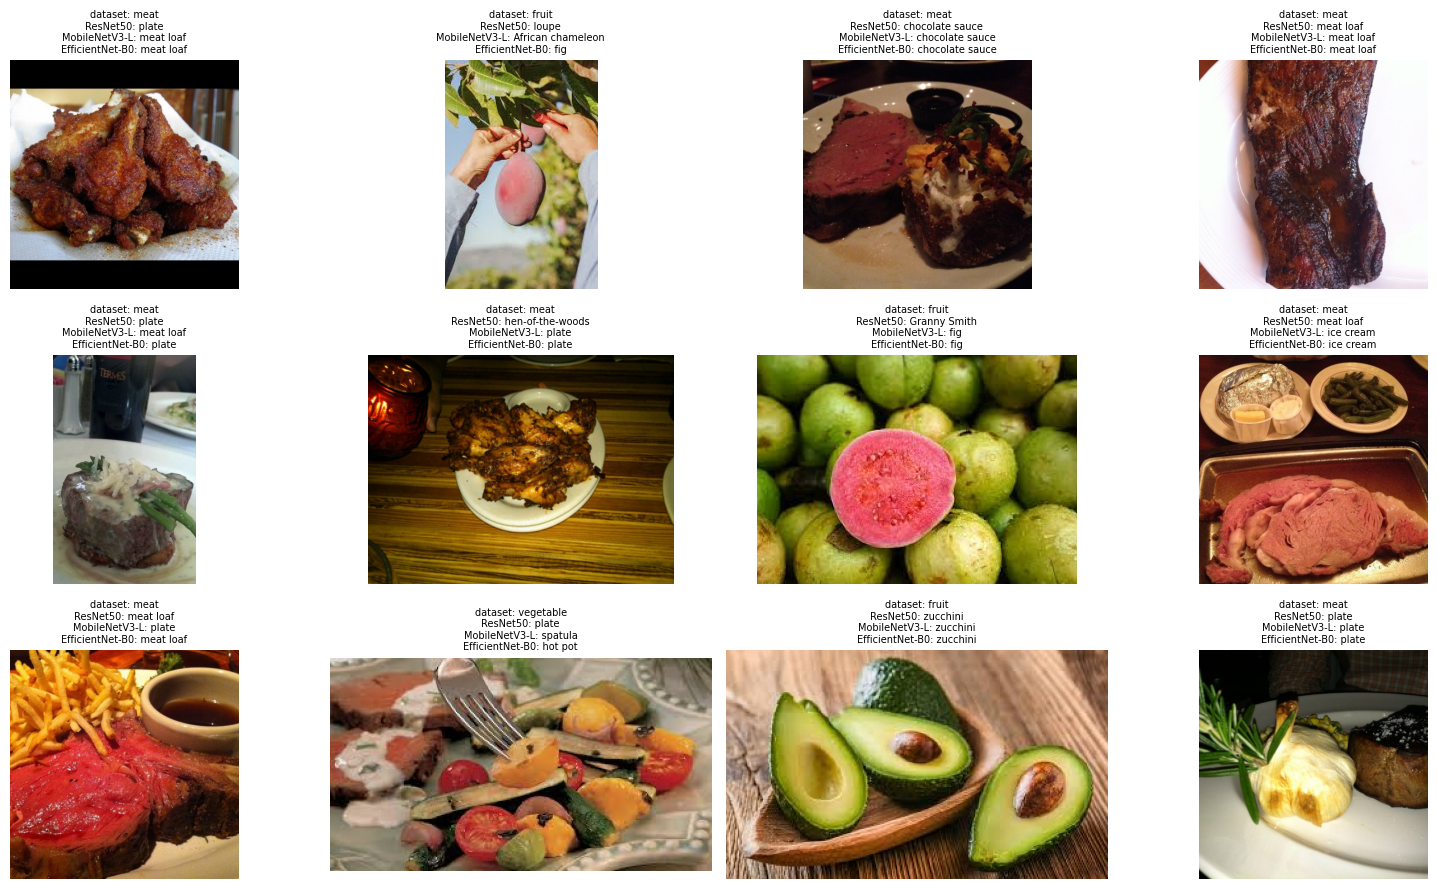

In [18]:
# Compare 3 pretrained ImageNet models (no training) on the tricky images.

MODEL_SPECS = [
    ("ResNet50", models.resnet50, ResNet50_Weights.IMAGENET1K_V2),
    ("MobileNetV3-L", models.mobilenet_v3_large, MobileNet_V3_Large_Weights.IMAGENET1K_V2),
    ("EfficientNet-B0", models.efficientnet_b0, EfficientNet_B0_Weights.IMAGENET1K_V1),
]

def count_params(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

def load_images(items):
    images = []
    for it in items:
        # Using .copy() avoids keeping a file handle open on some systems
        with Image.open(it["path"]) as im:
            images.append(im.convert("RGB").copy())
    return images

def run_model(model, preprocess, images, reps=5):
    x = torch.stack([preprocess(im) for im in images]).to(device)

    # Warmup (helps timing stability)
    with torch.inference_mode():
        _ = model(x)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    with torch.inference_mode():
        for _ in range(reps):
            logits = model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()

    ms_per_img = 1000.0 * (time.time() - t0) / (reps * len(images))

    probs = torch.softmax(logits, dim=1).detach().cpu()
    top1_prob, top1_idx = probs.max(dim=1)
    return top1_idx.tolist(), top1_prob.tolist(), ms_per_img

images = load_images(test_samples)

results_rows = []
preds = {
    "image": [os.path.basename(it["path"]) for it in test_samples],
    "dataset_label": [it["dataset_label"] for it in test_samples],
}

for short_name, builder, weights in MODEL_SPECS:
    print("Running:", short_name)
    model = builder(weights=weights).to(device).eval()
    preprocess = weights.transforms()
    categories = weights.meta.get("categories", None)

    top1_idx, top1_prob, ms_per_img = run_model(model, preprocess, images, reps=5)

    if categories is None:
        top1_label = [str(i) for i in top1_idx]
    else:
        top1_label = [categories[i] for i in top1_idx]

    preds[f"{short_name}_top1"] = top1_label
    preds[f"{short_name}_p"] = [float(p) for p in top1_prob]

    results_rows.append(
        {
            "model": short_name,
            "params_M": round(count_params(model) / 1e6, 2),
            "input": "224x224",
            "ms_per_image": round(float(ms_per_img), 2),
            "avg_top1_conf": round(float(np.mean(top1_prob)), 3),
        }
    )

results_df = pd.DataFrame(results_rows)
preds_df = pd.DataFrame(preds)

print("\nResults:")
print(results_df[["model", "params_M", "input", "ms_per_image", "avg_top1_conf"]].to_string(index=False))

print("\nPer-image predictions (top-1 ImageNet label):")
print(preds_df.to_string(index=False))

# Visualize: each image with the 3 model top-1 labels
cols = 4
rows = int(np.ceil(len(images) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):
    ax.axis("off")
    if i >= len(images):
        continue

    ax.imshow(images[i])
    title_lines = [f"dataset: {test_samples[i]['dataset_label']}"]
    for short_name, _, _ in MODEL_SPECS:
        title_lines.append(f"{short_name}: {preds[f'{short_name}_top1'][i]}")
    ax.set_title("\n".join(title_lines), fontsize=7)

plt.tight_layout()
plt.show()